# 개요

- 두 이미지 사이에서 **각 픽셀이 어디로 움직였는지**(flow)를 밝기 변화만으로 추정한다.
- 특징점 매칭과 달리 descriptor 없이, 미소 변위 가정과 이미지 미분만으로 대응을 만든다.

# 1. Optical Flow

- Feature matching (SIFT 등)
	- Descriptor를 계산해 멀리 떨어진 대응도 찾지만, 희소하고 비싸다
- Optical Flow
	- 밝기 항상성 + 1차 Taylor로 미소 변위를 푼다. 조밀하고 싸지만 작은 변위만

---
## 1.1. Brightness Constancy와 제약식

같은 점은 프레임이 바뀌어도 밝기가 같다는 가정에서 출발한다.

$$ I_{0}(x, y) = I_{1}(x + u, y + v) $$

- $I_{0}, I_{1}$: 연속한 두 프레임
- $(u, v)$: 픽셀 $(x,y)$의 flow

우변을 1차 Taylor로 전개하면:

$$ I_{1}(x + u, y + v) \approx I_{1}(x, y) + I_{x}u + I_{y}v $$

$I_{t} \equiv I_{1} - I_{0}$ 로 두고 정리하면 `Optical Flow Constraint`를 얻는다.

$$
\boxed{
I_{x}u + I_{y}v + I_{t} = 0
}
$$

- $I_{x}, I_{y}$: 공간 미분
- $I_{t}$: 시간 미분, 즉 두 프레임의 밝기 차이

즉,

> 밝기 차이는 밝기 기울기를 따라 픽셀이 움직인 만큼 생긴다

미지수는 $u, v$ 두 개인데 식은 픽셀당 하나뿐이다. 이것이 `aperture problem`이고,
한 픽셀만 봐서는 flow가 결정되지 않는다.

---
## 1.2. Lucas-Kanade: 창 안에서 flow가 같다고 본다

부족한 식을 이웃에서 빌려온다. 창 $W$ 안의 픽셀들이 같은 $(u,v)$를 갖는다고 가정하면,
픽셀마다 식이 하나씩 생겨 과결정 문제가 된다.

픽셀 $p$의 잔차는 다음과 같다:

$$ r_{p} = I_{x_p}u + I_{y_p}v + I_{t_p} $$

목적함수는 창 안 잔차의 제곱합이다.

$$
\boxed{
\min_{u, v} \sum_{p \in W} \left( I_{x_p}u + I_{y_p}v + I_{t_p} \right)^{2}
}
$$

잔차를 $\delta = [u, v]^{T}$ 로 미분하면 Jacobian은 픽셀당 $1 \times 2$ 이다.

$$ J_{p} = \frac{\partial r_{p}}{\partial \delta} = \begin{bmatrix} I_{x_p} & I_{y_p} \end{bmatrix} $$

---
## 1.3. Normal Equation

LiDAR BA와 똑같은 Gauss-Newton 구조다. 창 안의 Jacobian을 쌓아 $H$와 $g$를 만든다.

$$
\boxed{
H = J^{T}J = \begin{bmatrix}
\sum I_{x}^{2} & \sum I_{x}I_{y} \\
\sum I_{x}I_{y} & \sum I_{y}^{2}
\end{bmatrix},
\qquad
g = J^{T}r = \begin{bmatrix} \sum I_{x}I_{t} \\ \sum I_{y}I_{t} \end{bmatrix}
}
$$

$g$에 $I_{t}$만 남는 것은 $\delta = 0$ 에서 전개했기 때문이다. 즉 $r_{p} = I_{t_p}$ 이다.

따라서 update는 BA와 같은 식을 푼다.

$$ \boxed{ H \delta = -g } $$

$H$는 이미지의 `structure tensor`이고, Harris corner detector가 쓰는 그 행렬이다.
두 고유값 $\lambda_{1} \ge \lambda_{2}$ 가 이 창에서 flow를 풀 수 있는지를 말해준다.

| $\lambda_{2}$ | 창의 모습 | 결과 |
|---|---|---|
| $\approx 0$, $\lambda_1 \approx 0$ | 평평한 영역 | $H$ 특이. 아무 방향도 못 정한다 |
| $\approx 0$, $\lambda_1 \gg 0$ | edge | edge 방향 성분만 미정 (aperture problem) |
| $\gg 0$ | corner / texture | 유일해 |

코드에서는 역행렬을 만들지 않고 $\det H$ 로 가려낸 뒤 $2\times2$ 를 닫힌 형태로 푼다.

---
## 1.4. 반복 정련

1차 Taylor는 변위가 1픽셀 안팎일 때만 맞다. 그래서 한 번에 풀지 않고, 현재 추정으로
$I_{1}$ 을 끌어온 뒤 남은 변위를 다시 푼다.

$$
\boxed{
I_{t}(p) = I_{1}(x + p) - I_{0}(x),
\qquad
p \leftarrow p + \delta p
}
$$

- $p$: 지금까지 누적된 flow

$I_{x}, I_{y}$ 는 항상 $I_{0}$ 에서 계산한다. 그러면 $H$ 가 반복 내내 상수라 한 번만 만들면 된다.
여기서 warp가 픽셀별 평행이동이므로 additive update와 compositional update가 같다.

---
## 1.5. Pyramid: coarse-to-fine

반복해도 변위가 창 크기를 넘으면 시작조차 못 한다. 이미지를 절반씩 줄이면 변위도 절반이 되므로,
거친 레벨에서 큰 변위를 잡고 내려오면서 다듬는다.

레벨 $L$ 에서 구한 flow를 한 단계 아래로 넘길 때는 해상도가 두 배가 되므로 크기도 두 배다.

$$ \boxed{ p^{L-1} = 2 \cdot \mathrm{upsample}(p^{L}) } $$

---
## 1.6. 실무 보정: flow median filter

픽셀마다 독립으로 풀기 때문에, $\lambda_2$ 가 작은 픽셀은 반복할수록 폭주한다. 반복 사이에
flow를 median filter로 한 번 눌러주면 이 폭주가 이웃에 전파되지 않는다.

$$ \boxed{ p \leftarrow \mathrm{median}_{5 \times 5}(p) } $$

평균이 아니라 median인 이유는, 평균은 폭주한 값에 그대로 끌려가지만 median은 무시하기 때문이다.
(Sun et al., *Secrets of Optical Flow Estimation*, CVPR 2010)

---
## 1.7. 전체 파이프라인

$$
\boxed{
I_{x},I_{y},I_{t} \rightarrow H = J^{T}J,\; g = J^{T}r \rightarrow H\delta = -g
\rightarrow p \leftarrow p + \delta p \rightarrow \mathrm{median} \rightarrow \text{pyramid up}
}
$$

```txt
Level 2 (1/4)   I0 ──┐                 큰 변위를 여기서 잡는다
                I1 ──┴─ LK 반복 ─ p2
                         │ x2
Level 1 (1/2)   I0 ──┐   ↓
                I1 ──┴─ LK 반복 ─ p1
                         │ x2
Level 0 (원본)  I0 ──┐   ↓
                I1 ──┴─ LK 반복 ─ p0  ← 최종 flow
```

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter, zoom

np.set_printoptions(precision=3, suppress=True)
plt.rcParams["figure.dpi"] = 110

# 한글 폰트가 있으면 쓴다. 없으면 그림의 한글 라벨이 네모로 나온다.
from matplotlib import font_manager
_available = {f.name for f in font_manager.fontManager.ttflist}
for _name in ("Apple SD Gothic Neo", "AppleGothic", "NanumGothic",
              "Malgun Gothic", "Noto Sans CJK KR", "Arial Unicode MS"):
    if _name in _available:
        plt.rcParams["font.family"] = _name
        plt.rcParams["axes.unicode_minus"] = False
        plt.rcParams["mathtext.fontset"] = "dejavusans"   # 수식은 계속 DejaVu 로
        break

## 0. 샘플 데이터 생성하기

- `flow_simulator.py` 가 **참값 flow를 아는** 이미지 쌍을 만든다.
- 초기 추정은 flow = 0 이다. 알고리즘이 할 일이 실제로 남아 있어야 검증이 의미를 갖는다.

In [2]:
import importlib
import flow_simulator
importlib.reload(flow_simulator)          # 커널을 재시작하지 않아도 최신 버전을 반영
from flow_simulator import *

spec = FlowSpec(height=192,
                width=240,
                texture_scale=2.0,
                kind="rotation",          # translation | rotation | divergence
                amount=5.0)               # rotation 이면 회전각[deg]
pair = make_flow_data(spec, seed=0)

# 초기 추정: 아무것도 모른다는 뜻의 0
flow_init = np.zeros(pair.I0.shape + (2,))

print("이미지     :", pair.I0.shape)
print("최대 변위  : %.2f px" % np.linalg.norm(pair.flow, axis=-1).max())
print("초기 EPE   : %.3f px" % endpoint_error(flow_init, pair.flow))

이미지     : (192, 240)
최대 변위  : 13.35 px
초기 EPE   : 6.707 px


# 1. 데이터 시각화

Jacobian을 쓰기 전에 입력이 어떻게 생겼는지 먼저 본다. `I1 - I0` 가 0이 아닌 곳이
알고리즘이 신호를 얻을 수 있는 곳이다.

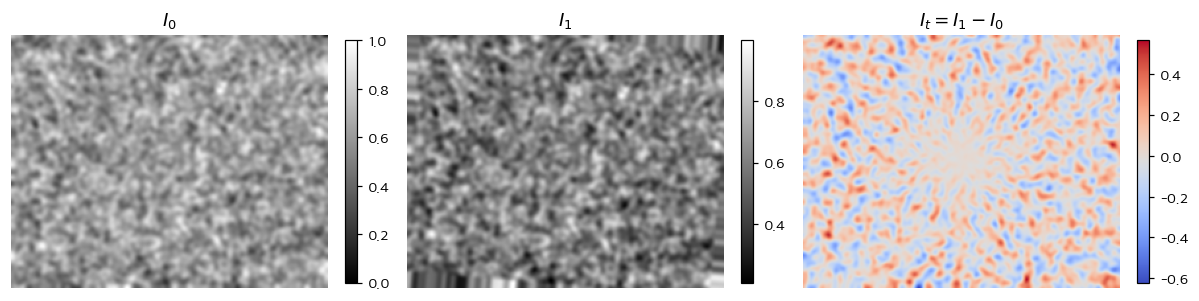

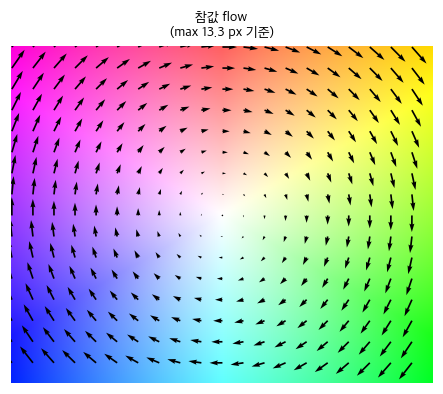

In [3]:
def show_pair(pair):
    """두 프레임과 그 차이. 차이 영상이 곧 I_t 이다."""
    fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
    for ax, img, title in zip(axes,
                              [pair.I0, pair.I1, pair.I1 - pair.I0],
                              ["$I_0$", "$I_1$", "$I_t = I_1 - I_0$"]):
        im = ax.imshow(img, cmap="gray" if title != "$I_t = I_1 - I_0$" else "coolwarm")
        ax.set_title(title); ax.axis("off")
        fig.colorbar(im, ax=ax, fraction=0.035)
    plt.tight_layout(); plt.show()


def show_flow(flows, titles, max_magnitude=None, step=12):
    """flow를 색(방향)과 화살표로. 여러 flow를 비교하려면 max_magnitude를 공유해야 한다."""
    flows = list(flows)
    if max_magnitude is None:
        max_magnitude = max(np.linalg.norm(f, axis=-1).max() for f in flows)

    fig, axes = plt.subplots(1, len(flows), figsize=(4.2 * len(flows), 3.6))
    axes = np.atleast_1d(axes)
    height, width = flows[0].shape[:2]
    y, x = np.mgrid[0:height:step, 0:width:step]

    for ax, flow, title in zip(axes, flows, titles):
        ax.imshow(flow_to_rgb(flow, max_magnitude))
        ax.quiver(x, y, flow[::step, ::step, 0], -flow[::step, ::step, 1],
                  color="k", scale=max_magnitude * 18, width=0.004)
        ax.set_title(f"{title}\n(max {max_magnitude:.1f} px 기준)", fontsize=9)
        ax.axis("off")
    plt.tight_layout(); plt.show()


show_pair(pair)
show_flow([pair.flow], ["참값 flow"])

# 2. Lucas-Kanade

박스 수식 하나에 셀 하나씩 대응시킨다.

In [4]:
# 1. 이미지 미분 - I_x, I_y, I_t
def flow_derivatives(I0, I1, flow):
    """I_x, I_y 는 I_0 에서만 구한다 (1.4절) → H 가 반복 내내 상수다.

    I_t 만 현재 flow 로 warp 한 I_1 에서 다시 계산한다.
    """
    Ix, Iy = image_gradients(I0)              # (H, W), (H, W)
    It = warp_to_source(I1, flow) - I0        # (H, W)
    return Ix, Iy, It

In [5]:
# 2. Structure tensor - H = J^T J, g = J^T r
def normal_equation(Ix, Iy, It, window=15):
    """창 합으로 픽셀마다 2x2 H 와 2x1 g 를 만든다. 반환은 성분별 (H, W) 배열이다."""
    Hxx = window_sum(Ix * Ix, window)
    Hxy = window_sum(Ix * Iy, window)
    Hyy = window_sum(Iy * Iy, window)
    gx = window_sum(Ix * It, window)
    gy = window_sum(Iy * It, window)
    return Hxx, Hxy, Hyy, gx, gy

In [6]:
# 3. H delta = -g 풀기
def solve_flow_update(Hxx, Hxy, Hyy, gx, gy, min_eig=1e-3):
    """2x2 라 역행렬을 닫힌 형태로 쓴다.

        H^-1 = 1/det * [[Hyy, -Hxy], [-Hxy, Hxx]],   delta = -H^-1 g

    작은 고유값이 min_eig 미만이면 aperture problem 영역이라 0 을 준다 (1.3절).
    그대로 나눠 버리면 그 픽셀이 폭주해 이웃까지 오염시킨다.
    """
    trace = Hxx + Hyy
    disc = np.sqrt(np.maximum((Hxx - Hyy) ** 2 + 4.0 * Hxy ** 2, 0.0))
    lambda_min = 0.5 * (trace - disc)             # (H, W)
    det = Hxx * Hyy - Hxy * Hxy

    ok = (lambda_min > min_eig) & (det > 1e-12)
    safe_det = np.where(ok, det, 1.0)             # 나눗셈 경고를 막는 더미
    du = np.where(ok, -(Hyy * gx - Hxy * gy) / safe_det, 0.0)
    dv = np.where(ok, -(Hxx * gy - Hxy * gx) / safe_det, 0.0)
    return np.stack([du, dv], axis=-1), ok        # (H, W, 2), (H, W)

In [7]:
# 4. flow median filter - p <- median(p)
def smooth_flow(flow, size=5):
    """폭주한 픽셀이 이웃으로 번지는 것을 막는다 (1.6절). u, v 를 따로 거른다."""
    return np.stack([median_filter(flow[..., k], size=size, mode="nearest")
                     for k in (0, 1)], axis=-1)

In [8]:
# 5. 피라미드 레벨 간 전달 - p^{L-1} = 2 * upsample(p^L)
def upscale_flow(flow, shape):
    """해상도가 두 배가 되므로 flow 크기도 두 배다 (1.5절)."""
    zoom_factor = (shape[0] / flow.shape[0], shape[1] / flow.shape[1], 1)
    return zoom(flow, zoom_factor, order=1) * 2.0

In [9]:
# 6. LK 한 스텝 - 위 1~4 를 묶는다
def lk_step(I0, I1, flow, window=15, min_eig=1e-3):
    Ix, Iy, It = flow_derivatives(I0, I1, flow)
    Hxx, Hxy, Hyy, gx, gy = normal_equation(Ix, Iy, It, window)
    delta, ok = solve_flow_update(Hxx, Hxy, Hyy, gx, gy, min_eig)
    rms = float(np.sqrt(np.mean(It ** 2)))        # 남은 밝기 잔차
    return smooth_flow(flow + delta), rms, ok

## 2.1. 먼저 단일 레벨로 돌려본다

피라미드가 왜 필요한지 보려면, 없이 돌려서 실패하는 것을 봐야 한다.

In [10]:
iteration = 6
window = 15

flow_single = flow_init.copy()
rms_single = []

for it in range(iteration):
    flow_single, rms, ok = lk_step(pair.I0, pair.I1, flow_single, window)
    rms_single.append(rms)
    print(f"it {it}  rms(I_t) = {rms:.4f}   EPE = {endpoint_error(flow_single, pair.flow):.3f} px"
          f"   유효 픽셀 {ok.mean() * 100:.1f}%")

it 0  rms(I_t) = 0.1312   EPE = 6.016 px   유효 픽셀 100.0%
it 1  rms(I_t) = 0.1186   EPE = 5.442 px   유효 픽셀 100.0%
it 2  rms(I_t) = 0.1093   EPE = 5.049 px   유효 픽셀 100.0%
it 3  rms(I_t) = 0.1019   EPE = 4.753 px   유효 픽셀 100.0%
it 4  rms(I_t) = 0.0955   EPE = 4.521 px   유효 픽셀 100.0%
it 5  rms(I_t) = 0.0898   EPE = 4.340 px   유효 픽셀 100.0%


## 2.2. Pyramid Lucas-Kanade

메인 루프. 주석 번호가 1.7절 파이프라인 박스와 그대로 대응한다.

In [11]:
levels = 3
iteration = 6
window = 15

# 0. 두 이미지의 피라미드 - [0] 이 원본, 뒤로 갈수록 거칠다
pyr0 = build_pyramid(pair.I0, levels)
pyr1 = build_pyramid(pair.I1, levels)

# 가장 거친 레벨에서 flow = 0 으로 시작
flow = np.zeros(pyr0[-1].shape + (2,))
history = []

for level in range(levels - 1, -1, -1):
    # 5. 이전(거친) 레벨의 flow 를 현재 해상도로 올린다
    if level < levels - 1:
        flow = upscale_flow(flow, pyr0[level].shape)

    for it in range(iteration):
        # 1~4. I_x,I_y,I_t -> H,g -> H delta = -g -> p+delta -> median
        flow, rms, ok = lk_step(pyr0[level], pyr1[level], flow, window)
        history.append({"level": level, "iter": it, "rms": rms,
                        "valid": float(ok.mean())})

    print(f"level {level} ({pyr0[level].shape})  rms(I_t) = {rms:.4f}"
          f"   EPE = {endpoint_error(flow, pair.flow) if level == 0 else float('nan'):.3f} px")

flow_pyramid = flow

level 2 ((48, 60))  rms(I_t) = 0.0324   EPE = nan px
level 1 ((96, 120))  rms(I_t) = 0.0349   EPE = nan px


level 0 ((192, 240))  rms(I_t) = 0.0316   EPE = 0.992 px


# 3. 검증

돌아간다는 것과 맞다는 것은 다르다. 참값이 있으니 숫자로 채점한다.

- `EPE` (endpoint error): 픽셀당 flow 벡터 오차의 평균 [px]

In [12]:
epe_zero = endpoint_error(flow_init, pair.flow)
epe_single = endpoint_error(flow_single, pair.flow)
epe_pyramid = endpoint_error(flow_pyramid, pair.flow)

print(f"최대 변위        : {np.linalg.norm(pair.flow, axis=-1).max():.2f} px")
print(f"EPE  flow=0      : {epe_zero:.3f} px")
print(f"EPE  단일 레벨   : {epe_single:.3f} px   ({epe_zero / epe_single:.1f}x 개선)")
print(f"EPE  피라미드 3  : {epe_pyramid:.3f} px   ({epe_zero / epe_pyramid:.1f}x 개선)")

최대 변위        : 13.35 px
EPE  flow=0      : 6.707 px
EPE  단일 레벨   : 4.340 px   (1.5x 개선)
EPE  피라미드 3  : 0.992 px   (6.8x 개선)


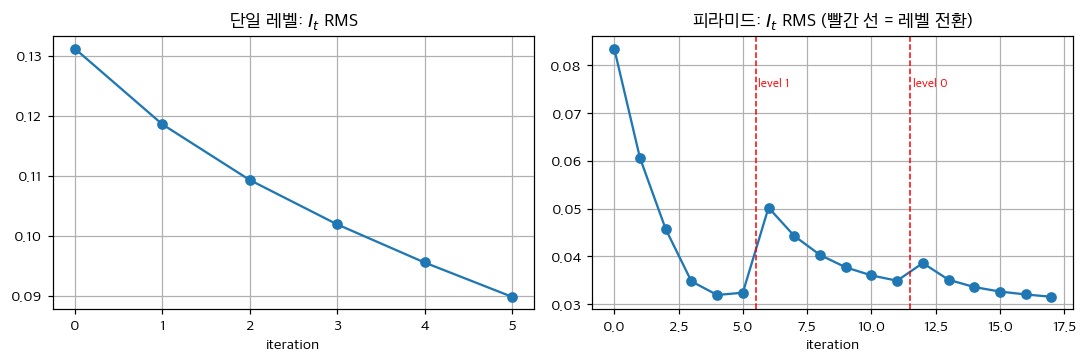

In [13]:
# 수렴 곡선 - 레벨이 바뀌는 지점을 표시한다
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))

axes[0].plot(rms_single, "o-")
axes[0].set_title("단일 레벨: $I_t$ RMS"); axes[0].set_xlabel("iteration")
axes[0].grid(True)

rms_pyr = [h["rms"] for h in history]
axes[1].plot(rms_pyr, "o-")
for k, h in enumerate(history):
    if k and h["level"] != history[k - 1]["level"]:
        axes[1].axvline(k - 0.5, color="r", ls="--", lw=1)
        axes[1].text(k - 0.4, max(rms_pyr) * 0.9, f"level {h['level']}", fontsize=8, color="r")
axes[1].set_title("피라미드: $I_t$ RMS (빨간 선 = 레벨 전환)")
axes[1].set_xlabel("iteration"); axes[1].grid(True)

plt.tight_layout(); plt.show()

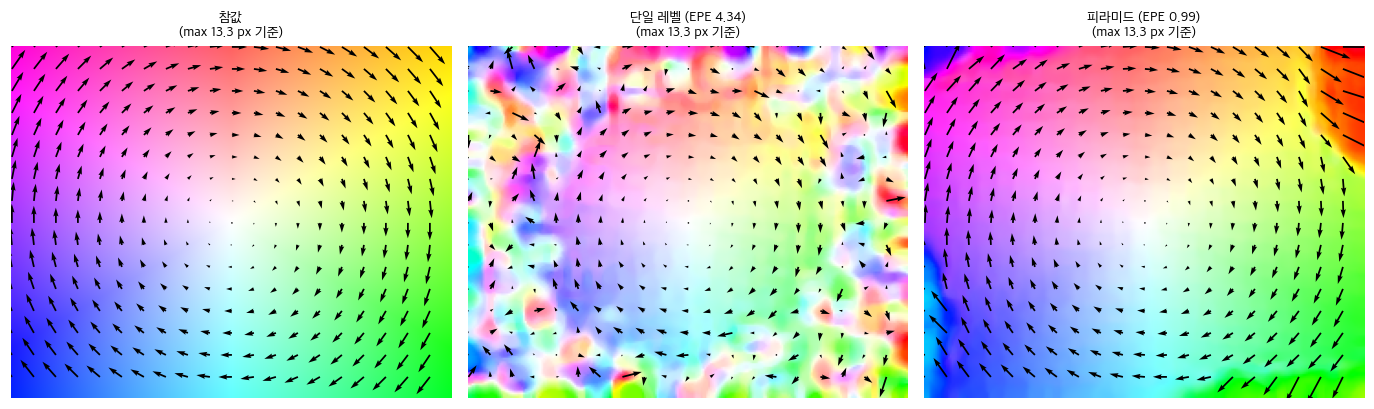

In [14]:
# before / after - 같은 함수, 같은 색 기준으로 그려야 비교가 된다
show_flow([pair.flow, flow_single, flow_pyramid],
          ["참값", f"단일 레벨 (EPE {epe_single:.2f})", f"피라미드 (EPE {epe_pyramid:.2f})"],
          max_magnitude=np.linalg.norm(pair.flow, axis=-1).max())

## 3.1. 레벨 수는 많을수록 좋은가

아니다. 레벨을 올릴수록 blur가 texture를 지워 $H$ 가 퇴화하고, 거기서 생긴 오차가
아래 레벨로 그대로 증폭되어 내려온다. 이 노트북 설정에서는 3레벨이 바닥이다.

In [15]:
def pyramidal_lk(I0, I1, levels, iteration=6, window=15):
    """위 메인 루프와 같은 내용을 레벨 수만 바꿔 재실행하기 위한 함수."""
    p0, p1 = build_pyramid(I0, levels), build_pyramid(I1, levels)
    flow = np.zeros(p0[-1].shape + (2,))
    for level in range(levels - 1, -1, -1):
        if level < levels - 1:
            flow = upscale_flow(flow, p0[level].shape)
        for _ in range(iteration):
            flow, _, _ = lk_step(p0[level], p1[level], flow, window)
    return flow


for lv in (1, 2, 3, 4, 5):
    epe = endpoint_error(pyramidal_lk(pair.I0, pair.I1, lv), pair.flow)
    print(f"levels = {lv}   EPE = {epe:7.3f} px")

levels = 1   EPE =   4.340 px
levels = 2   EPE =   1.895 px


levels = 3   EPE =   0.992 px
levels = 4   EPE =   3.952 px


levels = 5   EPE =  31.677 px


## 3.2. 한계

기록해 둘 실패들이다. 고쳐서 감추는 것보다 남겨두는 쪽이 쓸모 있다.

- **큰 변위**: 위 sweep에서 보듯 레벨이 모자라면 아예 수렴하지 않는다. 변위가 창 크기를
  넘으면 1차 Taylor가 성립하지 않는다.
- **밝기 변화**: `FlowSpec(noise=...)` 를 올리면 brightness constancy 가 깨져 EPE가 바로 나빠진다.
  실제 영상의 노출 변화·그림자가 여기 해당한다.
- **occlusion**: 이 시뮬레이터에는 가림이 없다. 가려진 픽셀은 대응 자체가 없어서
  LK가 아무 값이나 만들어 내는데, 이 노트북은 그것을 재현하지 않는다.
- **median filter 의존**: 1.6절을 빼면 반복할수록 발산한다. 직접 `smooth_flow` 를
  항등함수로 바꿔 돌려 보면 확인된다.